In [ ]:
import sys

sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")
import torch

%load_ext autoreload
%autoreload 2    
from utilities import panelize, rgb
from main import load_and_process_config
from dataset import from_config
from main import create_model_from_config

config = load_and_process_config("config_train.yaml")
config.DATASETS = {"SCARED": config.DATASETS.SCARED}
dataset = from_config(config)["training"]
idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True))
from polar_highlighter import PolarHighlighter, get_soft_highlight_map

ph = PolarHighlighter(
    width=config.MODEL.RGB_ENCODER.IMAGE_SIZE,
    height=config.MODEL.RGB_ENCODER.IMAGE_SIZE,
).cuda()
model = create_model_from_config(config, "cuda")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


DATASET  [22:53:08] Processing 1 datasets: ['SCARED']

DATASET  [22:53:08] Using all scenes except VAL_SCENES for SCARED training

DATASET  [22:53:08]   ✓ Created training dataset for SCARED: 25393 samples (excluding 1 val scenes)

DATASET  [22:53:08]   ✓ Created validation dataset for SCARED: 88 samples from 1 scenes

...

MODEL    [22:53:10] Decoder 'diffuse' un-frozen due to DECODER_LR=1e-05

MODEL    [22:53:10] Decoder 'highlight' un-frozen due to DECODER_LR=0.0005

MODEL    [22:53:10] ✓ Token Inpainter: Successfully loaded all 78 state dict keys from weights/token_inpainter.pth

MODEL    [22:53:11] Loaded pretrained token inpainter weights from weights/token_inpainter.pth

MODEL    [22:53:11] Model with class UnReflect_Model_TokenInpainter created with 498,003,972 parameters

In [ ]:
# config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["validation"]
light_pos = torch.tensor([0.0, 0.1, -0.1]).cuda()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)
idataloadr = iter(dataloader)
batch = next(idataloadr)
# batch = next(idataloadr)

image = batch["raw"].cuda(non_blocking=True)
# from PIL import Image
# from torchvision import transforms
# image = Image.open("/home/atuin/v120bb/v120bb18/UnReflectAnything/Picture1.jpg")
# image = transforms.ToTensor()(image).cuda()
# image.shape


DATASET  [22:53:17] Processing 1 datasets: ['SCARED']

DATASET  [22:53:17] Using all scenes except VAL_SCENES for SCARED training

DATASET  [22:53:17]   ✓ Created training dataset for SCARED: 25393 samples (excluding 1 val scenes)

DATASET  [22:53:17]   ✓ Created validation dataset for SCARED: 88 samples from 1 scenes

DATASET  [22:53:17] === Dataset Creation Summary ===

DATASET  [22:53:17] Training:   25393 total samples

DATASET  [22:53:17] Validation: 88 total samples

DATASET  [22:53:17] Test:       88 total samples

In [13]:
image.shape

torch.Size([1, 3, 896, 896])

In [14]:
ph = PolarHighlighter(
    width=896,
    height=896,
).cuda()

In [ ]:
import os
import torchvision.utils as vutils

output_dir = "/home/atuin/v120bb/v120bb18/UnReflectAnything/irene"
os.makedirs(output_dir, exist_ok=True)

for i, sample in enumerate(dataloader):
    image = sample["raw"].cuda(non_blocking=True)
    out = ph(
        rgb=image,
        intensity=2,
        surface_roughness=8,
        return_dataset_highlights=True,
        dataset_highlight_dilation=config.DATASET_HIGHLIGHT_DILATION,
        dataset_highlight_threshold=0.875,
        # light_pos=out["light_pos"],
    )
    depthmap = rgb(
        out["depth"], colormap="magma", as_tensor=True
    )  # [B,3,H,W] or [3,896,896]
    # Save as PNG (normalize to [0,1] for safety)
    depthmap_to_save = depthmap
    if depthmap_to_save.dim() == 4:
        depthmap_to_save = depthmap_to_save[0]  # take first in batch if batched
    depthmap_to_save = depthmap_to_save.clamp(0, 1)
    vutils.save_image(
        depthmap_to_save,
        os.path.join(output_dir, f"depthmap_{i:05d}.png"),
    )
    print(
        f"Saved {os.path.join(output_dir, f'depthmap_{i:05d}.png')} shape {depthmap_to_save.shape}"
    )
    # Optionally break after some N if not needed for all
    # break

Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00000.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00001.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00002.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00003.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00004.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00005.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00006.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00007.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v120bb/v120bb18/UnReflectAnything/irene/depthmap_00008.png shape torch.Size([3, 896, 896])
Saved /home/atuin/v

In [ ]:
soft_highlight_map = torch.clamp(
    out["highlight"] * 3 + out["dataset_highlights_soft_mask"],
    0,
    1,
)
rgb_in = model.dinov3.preprocess_image(out["rgb_highlighted"])
from models import pixel_mask_to_patch_mask

hole_mask = pixel_mask_to_patch_mask(
    soft_highlight_map, 16, threshold=0.1, invert=True, soft=True
)
sup_mask = pixel_mask_to_patch_mask(
    out["dataset_highlights_soft_mask"], 16, threshold=0.5, invert=True
)
hole_and_sup_mask = hole_mask.int() + sup_mask.int()
rgb_tokens = model.dinov3(rgb_in)["selected_hidden_states"]

real_and_virtual_highlights = (out["highlight"] + soft_highlight_map).clamp(0, 1)


# rgb(batch["diffuse"][0], resize=(448, 448), as_tensor=False)
rgb(
    out["rgb_highlighted"][0],
    resize=(448, 448),
    as_tensor=False,
    colormap="gray",
)
rgb(batch["raw"][0], resize=(448, 448), as_tensor=False)
rgb(soft_highlight_map[0], resize=(448, 448), as_tensor=False, colormap="gray")
rgb(
    out["dataset_highlights_soft_mask"][0],
    resize=(448, 448),
    as_tensor=False,
    colormap="gray",
)
rgb_tokens = model.dinov3(rgb_in)["selected_hidden_states"]
_, pca = rgb(
    rgb_tokens[3].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2)[0],
    as_tensor=True,
    return_pca=True,
)
rgb(
    rgb_tokens[3].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2)[0]
    * (hole_mask.reshape(1, 1, 28, 28)[0].int()),
    as_tensor=False,
    scale=16,
    pca=pca,
    blackout=True,
)
rgb(
    1 - (hole_mask.reshape(1, 1, 28, 28)[0].int()),
    as_tensor=False,
    scale=16,
    colormap="gray",
)

rgb(
    1 - (sup_mask.reshape(1, 1, 28, 28)[0].int()),
    as_tensor=False,
    scale=16,
    colormap="gray",
)
rgb(
    hole_and_sup_mask.reshape(1, 1, 28, 28)[0].int(),
    as_tensor=False,
    scale=16,
    colormap="gnuplot2_r",
    # colormap="hsv",
)
rgb(
    rgb_tokens[3].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2)[0],
    as_tensor=False,
    scale=16,
    pca=pca,
    blackout=False,
)
real_and_virtual_highlights = (out["highlight"] + soft_highlight_map).clamp(0, 1)


In [ ]:
from main import create_model_from_config

model = create_model_from_config(config, "cuda")


In [ ]:
from models import pixel_mask_to_patch_mask

patch_mask = pixel_mask_to_patch_mask(soft_highlight_map, 16, threshold=0.5).float()
patch_mask_soft = pixel_mask_to_patch_mask(
    soft_highlight_map, 16, threshold=0.5, soft=True
).float()
rgb(
    panelize(
        rgb(soft_highlight_map[0], as_tensor=True, colormap="gray"),
        rgb(
            patch_mask.reshape(1, 1, 28, 28)[0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            patch_mask_soft.reshape(1, 1, 28, 28)[0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
    )
)

In [ ]:
rgb_in = model.dinov3.preprocess_image(out["rgb_highlighted"])
from models import pixel_mask_to_patch_mask

patch_mask = pixel_mask_to_patch_mask(
    soft_highlight_map, 16, threshold=0.5, invert=True
)
rgb_tokens = model.dinov3(rgb_in)["selected_hidden_states"]
_, pca = rgb(
    rgb_tokens[3].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2)[0],
    as_tensor=True,
    return_pca=True,
)
rgb(
    rgb_tokens[3].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2)[0]
    * patch_mask.reshape(1, 1, 28, 28)[0],
    as_tensor=False,
    scale=8,
    pca=pca,
    blackout=True,
)
rgb(
    1 - (patch_mask.reshape(1, 1, 28, 28)[0].int()),
    as_tensor=False,
    scale=8,
    colormap="gray",
)
rgb(
    rgb_tokens[3].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2)[0],
    as_tensor=False,
    scale=8,
    pca=pca,
    blackout=False,
)

In [ ]:
rgb(batch["raw"][0], resize=(448, 448), as_tensor=False)
rgb(batch["diffuse"][0].cuda(), resize=(448, 448), as_tensor=False)
rgb(
    torch.clamp(batch["specular"][0] * 10, 0, 1),
    resize=(448, 448),
    as_tensor=False,
)
# rgb(soft_highlight_map, resize=(224, 224), as_tensor=False, colormap="gray"),
rgb(out["highlight"][0], resize=(448, 448), as_tensor=False, colormap="gray")
# rgb(
#     out["rgb_highlighted"][0]*soft_highlight_map,
#     resize=(448, 448),
#     as_tensor=False,
#     colormap="gray",
# )
rgb(
    out["rgb_highlighted"][0],
    resize=(448, 448),
    as_tensor=False,
    colormap="gray",
)

In [ ]:
# rgb(
#     panelize(
#         rgb(image, resize=(224, 224), as_tensor=True),
#         rgb(out["normals"][0], resize=(224, 224), as_tensor=True),
#         rgb(out["highlight"][0], resize=(224, 224), as_tensor=True, colormap="gray"),
#         rgb(
#             out["rgb_highlighted"][0],
#             resize=(224, 224),
#             as_tensor=True,
#             colormap="gray",
#         ),
#     )
# )
# break

In [ ]:
config = load_and_process_config("config_train.yaml")

dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloadr = iter(dataloader)
batch = next(idataloadr)
rgb(
    panelize(
        rgb(batch["raw"][0], resize=(224, 224), as_tensor=True),
        rgb(batch["diffuse"][0], resize=(224, 224), as_tensor=True),
        rgb(
            batch["specular"][0],
            resize=(224, 224),
            as_tensor=True,
        ),
    )
)

In [ ]:
rgb(
    panelize(
        rgb(batch["raw"][0], resize=(448, 448), as_tensor=True),
        rgb(batch["diffuse"][0], resize=(448, 448), as_tensor=True),
        rgb(
            batch["specular"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
    )
)

In [ ]:
out.keys()

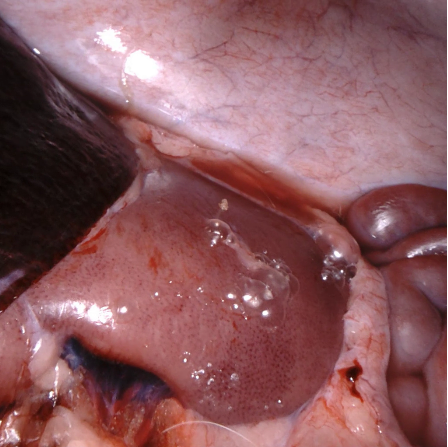

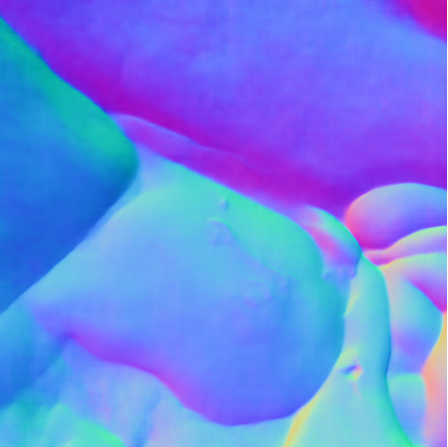

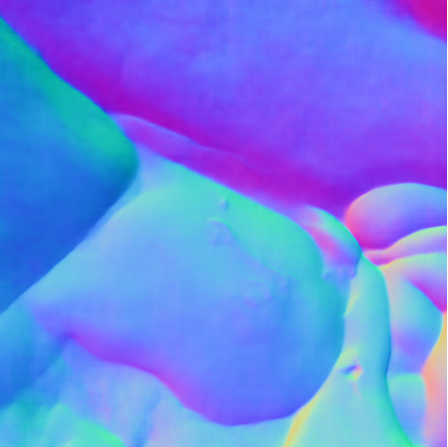

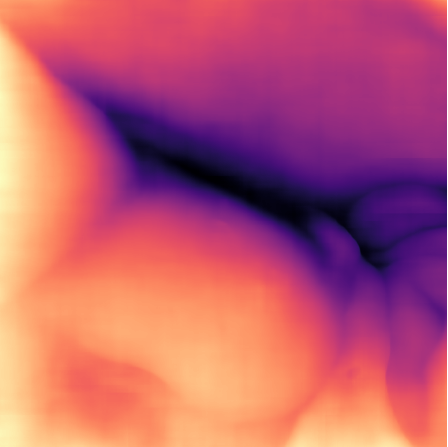

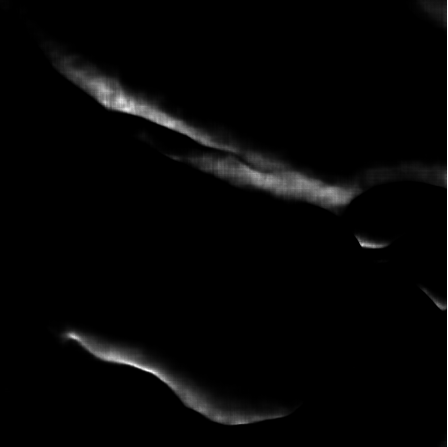

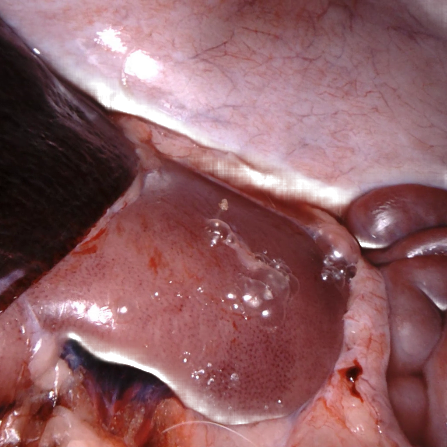

In [27]:
rgb(image, resize=(448, 448), as_tensor=False)
rgb(out["normals"][0], resize=(448, 448), as_tensor=False)
rgb(out["normals"][0], resize=(448, 448), as_tensor=False)

rgb(out["depth"][0], resize=(448, 448), as_tensor=False, colormap="magma_r")
rgb(out["highlight"][0], resize=(448, 448), as_tensor=False, colormap="gray")
rgb(
    out["rgb_highlighted"][0],
    resize=(448, 448),
    as_tensor=False,
    colormap="gray",
)

In [28]:
import rerun as rr
import numpy as np

rr.init("polar_highlighter")
rr.log("/", rr.ViewCoordinates.RDF)

# Prepare -45 deg rotation matrix around X axis for all scene data
theta_rad = -np.pi / 3  # -45 degrees
cos_t = np.cos(theta_rad)
sin_t = np.sin(theta_rad)
rotation_x_neg45 = np.array(
    [[1, 0, 0], [0, cos_t, -sin_t], [0, sin_t, cos_t]], dtype=np.float32
)


def apply_rotation(tensor, rot=rotation_x_neg45):
    # Handles [B, 3] or [N, 3] shape or [3]
    arr = tensor
    is_torch = False
    if hasattr(arr, "cpu"):
        arr = arr.cpu().numpy()
        is_torch = True
    arr = np.asarray(arr)
    # Add batch axis if needed
    shape = arr.shape
    if len(shape) == 1 and shape[0] == 3:
        arr_rot = rot @ arr
    elif len(shape) == 2 and shape[1] == 3:
        arr_rot = (rot @ arr.T).T
    elif len(shape) == 3 and shape[-2:] == (3, 1):
        arr = arr.reshape(-1, 3)
        arr_rot = (rot @ arr.T).T
    elif len(shape) == 2 and shape[0] == 3:  # (3, N)
        arr_rot = rot @ arr
    else:
        arr_rot = arr @ rot.T  # fallback, treat as [..., 3]
    return arr_rot


for light in range(20):
    random_light_pos = ph.sample_light_source(
        dist_to_camera=config.LIGHT_DISTANCE_RANGE,
        left_right_angle=config.LIGHT_LEFT_RIGHT_ANGLE,
        above_below_angle=config.LIGHT_ABOVE_BELOW_ANGLE,
        batch_size=1,
        device="cuda",
    )
    # out = ph(
    #     rgb=image,
    #     light_pos=out["light_pos"],
    #     intensity=config.INTENSITY,
    #     surface_roughness=config.SURFACE_ROUGHNESS,
    #     n_blobs=8,
    # )

    rotated_light_pos = apply_rotation(out["light_pos"].reshape(1, 3))
    rr.log(
        f"/light",
        rr.Points3D(
            positions=torch.tensor(rotated_light_pos)
            * torch.tensor([-1.0, 1.0, -1.0])
            * 0.25,
            colors=torch.tensor([1.0, 1.0, 1.0]).reshape(1, 3),
            radii=0.033,
        ),
    )
    if light == 0:
        intrinsic = out["intrinsic"]

        # Rotate the camera intrinsics by the same rotation (apply_rotation) for Rerun
        # Apply rotation to the intrinsic matrix: intrinsic[0] is (3, 3)
        # Rotate both the camera extrinsics and intrinsics for Rerun
        # For proper display in Rerun, the intrinsic matrix should match the camera orientation
        from rerun.datatypes import Angle, RotationAxisAngle

        rotation = RotationAxisAngle(
            axis=torch.tensor([1.0, 0.0, 0.0]),
            angle=Angle(rad=theta_rad),
        )
        rr.log(
            "/cam",
            rr.Transform3D(
                rotation=rotation,
                translation=torch.tensor([0, 0, 0]),
            ),
        )
        rr.log(
            "/cam/c",
            rr.Pinhole(
                image_from_camera=intrinsic[0]
                .cpu()
                .numpy(),  # rotate intrinsic accordingly
                resolution=(448, 448),
                # camera_xyz=apply_rotation(torch.tensor([1.0, 0.0, 0.0])),      # rotate principal axis
                image_plane_distance=0.1,
            ),
        )
        # for i in range(400):

    # Rotate the point cloud and rgb_highlighted
    pcloud = out["pcloud"].view(1, 3, -1)[0, :, ::1].permute(1, 0).cpu().numpy()
    pcloud_rot = apply_rotation(pcloud)
    rgb_highlighted = (
        batch["diffuse"].view(1, 3, -1)[0, :, ::1].permute(1, 0).cpu().numpy()
    )
    rr.log(
        "/pcloud",
        rr.Points3D(
            positions=pcloud_rot,
            colors=rgb_highlighted,  # probably doesn't need rotation
            # colors=out["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/out["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
        ),
    )
    # rr.notebook_show(width=1200, height=800)

    # Log normals as 3D arrows at each point in the point cloud
    CLOUD_DOWNS = 1
    ARROW_LENGTH = 0.2
    ARROW_RADIUS = 0.008
    # Example for Normals (commented out)
    # You'd want to rotate both the origins and the vectors for arrows
    # Uncomment and rotate for your use-case as needed
    #
    # norm_orig = (
    #     out["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
    #     .reshape(1, 3, -1)[0]
    #     .permute(1, 0)
    #     .cpu()
    #     .numpy()
    # )
    # norm_orig_rot = apply_rotation(norm_orig)
    # norm_vecs = (
    #     -out["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
    #     .reshape(1, 3, -1)[0]
    #     .permute(1, 0)
    #     .cpu()
    #     .numpy()
    #     * ARROW_LENGTH
    # )
    # norm_vecs_rot = apply_rotation(norm_vecs)
    # rr.log(
    #     "/normals",
    #     rr.Arrows3D(
    #         origins=norm_orig_rot,
    #         vectors=norm_vecs_rot,
    #         colors=torch.nn.functional.normalize(
    #             out["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
    #             .reshape(1, 3, -1)[0]
    #             .permute(1, 0),
    #             dim=1,
    #         )
    #         .cpu()
    #         .numpy()
    #         * 0.5
    #         + 0.5,
    #         radii=ARROW_RADIUS,
    #     ),
    # )
    # Repeat for light_dir and view_dir if visualizing those, rotate both origins & vectors.
rr.notebook_show(width=1500, height=800)


HTML(value='<div id="ba4f2907-d228-418f-9e6a-1aee7bd0b7a4"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

Viewer()

In [ ]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
for b, batch in enumerate(dataloader):
    image = batch["raw"].cuda(non_blocking=True)
    light_source = torch.tensor([-0.25, -0.5, 0.5]).cuda()
    out = ph(
        rgb=image,
        intensity=1.5,
        surface_roughness=20,
        light_pos=light_source,
    )
    # rgb(
    #     panelize(
    #         rgb(batch["raw"][0], resize=(448, 448), as_tensor=True),
    #         rgb(
    #             batch["diffuse"][0], resize=(448, 448), as_tensor=True
    #         ),
    #         rgb(
    #             batch["specular"][0],
    #             resize=(448, 448),
    #             as_tensor=True,
    #         ),
    #     )
    # )
    rgb(
        panelize(
            rgb(image, resize=(448, 448), as_tensor=True),
            rgb(out["normals"][0], resize=(448, 448), as_tensor=True),
            rgb(
                out["highlight"][0], resize=(448, 448), as_tensor=True, colormap="gray"
            ),
            rgb(
                out["rgb_highlighted"][0],
                resize=(448, 448),
                as_tensor=True,
                colormap="gray",
            ),
        )
    )
    break

In [ ]:
out["highlight"].shape

In [ ]:
from main import load_and_process_config
from dataset import from_config

config = load_and_process_config("config_train.yaml")
config.DATASETS = {"SCARED": config.DATASETS.SCARED}
dataset = from_config(config)["training"]

In [ ]:
config = load_and_process_config("config_train.yaml")

dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)
# light_pos = torch.tensor([0.0, 0.1, -0.1]).cuda()

for b, batch in enumerate(dataloader):
    image = batch["raw"].cuda(non_blocking=True)

    out = ph(
        rgb=image,
        light_pos=out["light_pos"],
        intensity=1.5,
        surface_roughness=10.0,
        # Geometric roughness parameters - high settings
        n_blobs=2,  # More blobs for high effect
        avg_blob_size=0.2,  # Larger blobs
        size_spread=0.5,  # More variation
        elongation_bias=0.7,  # More elongated
        falloff_mean=1,  # Softer edges
        falloff_jitter=0,  # More variation
        edge_wobble=1,  # More wobble
        warp_scale=1,  # Smaller scale
        min_separation=1,  # Less separation
        wavelength_px=8,  # Smaller wavelength
        wavelength_jitter=0.7,  # More variation
        orientation_anisotropy=0.6,  # More anisotropic
        octaves=4,  # More octaves
        roughness_strength=1,  # Full strength
        seed=None,  # Fixed seed for reproducibility
    )
    rgb(
        panelize(
            rgb(image, resize=(448, 448), as_tensor=True),
            rgb(out["normals"][0], resize=(448, 448), as_tensor=True),
            rgb(
                out["highlight"][0], resize=(448, 448), as_tensor=True, colormap="gray"
            ),
            rgb(
                out["rgb_highlighted"][0],
                resize=(448, 448),
                as_tensor=True,
                colormap="gray",
            ),
        ),
    )
    break

In [ ]:
rgb(outclean["rgb_highlighted"][0], resize=(448, 448))

In [ ]:
!uv pip install noise

In [ ]:
normals = outclean["normals"]

normals_noisy = add_geometric_roughness_torch(
    normals,
    n_blobs=24,  # more blobs
    avg_blob_size=0.10,  # smaller on average
    size_spread=0.1,  # many small, few larger
    elongation_bias=0.7,  # more elongated
    falloff_mean=0.30,  # softer edges
    falloff_jitter=0.25,  # varied softness
    edge_wobble=1,  # irregular borders
    warp_scale=10,
    wavelength_px=10.0,
    octaves=4,
    roughness_strength=0.20,  # intuitive strength knob
    seed=42,
)[0]

rgb(
    panelize(
        rgb(normals[0], resize=(448, 448), as_tensor=True),
        rgb(normals_noisy[0], resize=(448, 448), as_tensor=True),
    )
)


In [ ]:
# rgb(out_clean["normals"][0])
# rgb(
#     panelize(
#         rgb(
#             supervision_mask[0]*image[0],
#             resize=(448, 448),
#             as_tensor=True,
#             label={"position": "top-left", "height": 20, "margin": 4, "text": "'OLD' DIFF GT"},
#         ),
#         rgb(
#             batch["diffuse"][0],
#             resize=(448, 448),
#             as_tensor=True,
#             label={"position": "top-left", "height": 20, "margin": 4, "text": "DIFF"},
#         ),

#         # rgb(
#         #     batch["rgb"][0],
#         #     resize=(448, 448),
#         #     colormap="gray",
#         #     as_tensor=True,
#         #     label={"position": "top-left", "height": 20, "margin": 4, "text": "RGB"},
#         # )
#     )
# )



In [ ]:
rgb(
    batch["specular"][0],
    resize=(448, 448),
    # as_tensor=True,
    # label={"position": "top-left", "height": 20, "margin": 4, "text": "SPEC"},
)
rgb(
    batch["diffuse"][0],
    resize=(448, 448),
    # as_tensor=True,
    # label={"position": "top-left", "height": 20, "margin": 4, "text": "SPEC"},
)

rgb(
    batch["rgb"][0],
    resize=(448, 448),
    colormap="gray",
    # as_tensor=True,
    # label={"position": "top-left", "height": 20, "margin": 4, "text": "SPEC"},
)

In [ ]:
import cv2

cv2.edgePreservingFilter(
    batch["f_spec"][0].numpy(), flags=1, sigma_s=60, sigma_r=0.4
).shape


In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.log("/", rr.ViewCoordinates.RDF)
for light in range(1000):
    light_pos = ph.sample_light_source(
        dist_to_camera=(0.04, 0.2),
        left_right_angle=(0, 360),
        above_below_angle=(0, 360),
        batch_size=1,
        device="cuda",
    )
    result = ph(
        rgb=batch["rgb"].to("cuda", non_blocking=True),
        pol=None,
        light_pos=light_pos,
        intrinsic="compute",  # batch["intrinsics"].to("cuda", non_blocking=True),
        shininess=config.SHININESS,
        ks=config.KS,
    )
    rr.log(
        f"/light_{light}",
        rr.Points3D(
            positions=result["light_pos"].cpu().numpy().reshape(1, 3),
            colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
            radii=0.001,
        ),
    )
    if light == 0:
        intrinsic = result["intrinsic"]

        rr.log(
            "/cam",
            rr.Pinhole(
                image_from_camera=intrinsic[0].cpu().numpy(),  # (3, 3)
                resolution=(
                    448,
                    448,
                ),  # (2,)
                camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
            ),
        )
        # for i in range(400):

        rr.log(
            "/pcloud",
            rr.Points3D(
                positions=result["pcloud"]
                .view(1, 3, -1)[0]
                .permute(1, 0)
                .cpu()
                .numpy(),
                colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
                # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
            ),
        )
rr.notebook_show(width=1200, height=800)


# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 10
ARROW_LENGTH = 0.1
ARROW_RADIUS = 0.005
#
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
# light_dir = result["pcloud"] - result["light_pos"].unsqueeze(-1).unsqueeze(-1).repeat(1, 1, result["pcloud"].shape[2], result["pcloud"].shape[3])
# light_dir: [B, 3, H, W]
# light_dir = torch.nn.functional.normalize(light_dir, dim=1)  # Normalize along channel (3) dimension
# result["light_dir"] = -light_dir
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()a
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(
            result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0])
        .expand_as(
            result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.notebook_show(width=1700, height=800)


In [ ]:
rgb(
    panelize(
        rgb(
            batch["S0"][0],
            resize=(224, 224),
            as_tensor=True,
            colormap="jet",
            # label={"position": "top-left", "height": 40, "margin": 4, "text": "RGB"},
        ),
        rgb(
            batch["S1"][0],
            resize=(224, 224),
            as_tensor=True,
            colormap="jet",
            # label={"position": "top-left", "height": 40, "margin": 4, "text": "DIFF"},
        ),
        rgb(
            batch["S2"][0],
            resize=(224, 224),
            as_tensor=True,
            colormap="jet",
            # label={"position": "top-left", "height": 40, "margin": 4, "text": "SPEC"},
        ),
    )
)


In [ ]:
from models import RGBPOLDecomposer
from main import create_model_from_config

model = create_model_from_config(config, torch.device("cuda"))


In [ ]:
batch_gpu = {k: v.cuda() for k, v in batch.items()}
decomp = model(batch_gpu)

In [ ]:
decomp.keys()

In [ ]:
# pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()
intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892


result = ph(
    rgb=image,
    intrinsic=intrinsic_res,
    shininess=4,
    ks=1.5,
)
rgb(
    panelize(
        rgb(
            result["rgb_highlighted"][0],
            resize=(300, 300),
            as_tensor=True,
            # label={"position": "top-left", "height": 40, "margin": 4, "text": "Composition"},
        ),
        rgb(
            batch["rgb"][0],
            resize=(300, 300),
            as_tensor=True,
            # label={"position": "top-left", "height": 40, "margin": 4, "text": "RGB"},
        ),
        rgb(
            result["highlight"][0],
            resize=(300, 300),
            as_tensor=True,
            colormap="gray",
            label={
                "position": "top-left",
                "height": 40,
                "margin": 4,
                "text": "Highlight",
            },
        ),
    )
)
# break

In [ ]:
from dataset import from_config
from main import load_and_process_config

config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["training"]

In [ ]:
# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"]

rgb(
    panelize(
        rgb(
            batch["rgb"],
            as_tensor=False,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "RGB"},
        ),
        rgb(
            batch["diffuse"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "I-Diffuse",
            },
        ),
        rgb(
            batch["specular"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "I-Specular",
            },
        ),
        mode="horizontal",
    )
)

In [ ]:
# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break

rgb(
    panelize(
        rgb(
            batch["rgb"],
            as_tensor=True,
            resize=(400, 400),
            # border={"color": "#000000", "thickness": 1},
            label={"position": "top-left", "height": 40, "margin": 10, "text": "RGB"},
        ),
        rgb(
            -batch["AoP"],
            as_tensor=True,
            resize=(400, 400),
            # border={"color": "#00000", "thickness": 1},
            colormap="rainbow",
            label={
                "position": "top-left",
                "height": 40,
                "margin": 10,
                "text": "AoP",
                "style": "normal",
            },
        ),
        rgb(
            batch["DoP"],
            as_tensor=True,
            resize=(400, 400),
            # border={"color": "#00000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 40, "margin": 10, "text": "DoP"},
        ),
        mode="horizontal",
    )
)
rgb(
    panelize(
        rgb(
            batch["diffuse"],
            as_tensor=True,
            resize=(400, 400),
            # border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 40, "margin": 10, "text": "DIFF"},
        ),
        rgb(
            batch["specular"],
            as_tensor=True,
            resize=(400, 400),
            # border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 40, "margin": 10, "text": "SPEC"},
        ),
        mode="horizontal",
    )
)

In [ ]:
rgb(
    batch["rgb"],
    as_tensor=False,
    border={"color": "#000000", "thickness": 1},
    # colormap="jet",
    label={"position": "top-left", "height": 80, "margin": 20, "text": "RGB"},
)

In [ ]:
rgb(
    panelize(
        rgb(
            batch["I0"],
            as_tensor=True,
            border={"color": "#01CBCA", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I0"},
        ),
        rgb(
            batch["I45"],
            as_tensor=True,
            border={"color": "#F18222", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I45"},
        ),
        rgb(
            batch["I90"],
            as_tensor=True,
            border={"color": "#1B98FD", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I90"},
        ),
        rgb(
            batch["I135"],
            as_tensor=True,
            border={"color": "#01FEFE", "thickness": 20},
            label={"position": "top-left", "height": 80, "margin": 20, "text": "I135"},
        ),
        mode="horizontal",
    )
)
# rgb(
#     panelize(
#         rgb(batch["S0"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S1"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S2"], resize=(448, 448), as_tensor=True, colormap="gray"),
#     )
# )

In [ ]:
batch["S1"].min(), batch["S1"].max()

In [ ]:
rgb(
    panelize(
        rgb(
            batch["S0"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="jet",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "S0",
                "style": "normal",
            },
        ),
        rgb(
            batch["S1"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S1"},
        ),
        rgb(
            batch["S2"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S2"},
        ),
        mode="horizontal",
    )
)

In [ ]:
rgb(
    panelize(
        rgb(
            -batch["AoP"],
            as_tensor=True,
            border={"color": "#00000", "thickness": 1},
            colormap="rainbow",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "AoP",
                "style": "normal",
            },
        ),
        rgb(
            batch["DoP"],
            as_tensor=True,
            border={"color": "#00000", "thickness": 1},
            colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "DoP"},
        ),
        mode="horizontal",
    )
)

In [ ]:
rgb(
    panelize(
        rgb(
            batch["f_spec"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            colormap="gray",
            label={
                "position": "top-left",
                "height": 80,
                "margin": 20,
                "text": "S0",
                "style": "normal",
            },
        ),
        rgb(
            batch["diffuse"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S1"},
        ),
        rgb(
            batch["specular"],
            as_tensor=True,
            border={"color": "#000000", "thickness": 1},
            # colormap="jet",
            label={"position": "top-left", "height": 80, "margin": 20, "text": "S2"},
        ),
        mode="vertical",
    )
)

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()


In [ ]:
light_pos = torch.tensor([[4.4347, 9.7698, 0.0731]], device="cuda:0")
rgbh = []
rgbhh = []
shininesses = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
kses = [1, 1.5, 2]
for shininess in shininesses:
    for ks in kses:
        result = ph(
            rgb=image.cuda(),
            intrinsic=batch["intrinsics"].cuda(),
            shininess=shininess,
            light_pos=light_pos,
            ks=ks,
        )
        rgbh.append(
            rgb(result["rgb_highlighted"][0], resize=(200, 200), as_tensor=True)
        )
        rgbhh.append(
            rgb(
                (result["rgb_highlighted"][0].mean(dim=0) == 1).float(),
                resize=(200, 200),
                as_tensor=True,
            )
        )

rgb(panelize(*rgbh, mode="grid", grid_size=(len(shininesses), len(kses))))
rgb(panelize(*rgbhh, mode="grid", grid_size=(len(shininesses), len(kses))))

In [ ]:
dataset_highlights_soft_mask = get_soft_highlight_map(batch["rgb"].cuda(), 0.8)
inflated = (
    torch.nn.functional.max_pool2d(
        dataset_highlights_soft_mask, kernel_size=5, stride=1, padding=2
    )
    > 0
).int()
inflated2 = (
    torch.nn.functional.max_pool2d(
        dataset_highlights_soft_mask, kernel_size=5, stride=1, padding=2
    )
    > 0.25
).int()
inflated3 = (
    torch.nn.functional.max_pool2d(
        dataset_highlights_soft_mask, kernel_size=11, stride=1, padding=5
    )
    > 0
).int()
rgb(
    panelize(
        rgb(batch["rgb"], resize=(448, 448), as_tensor=True),
        rgb(
            dataset_highlights_soft_mask,
            resize=(448, 448),
            colormap="gray",
            as_tensor=True,
        ),
        rgb(inflated, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(inflated2, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(inflated2, resize=(448, 448), colormap="gray", as_tensor=True),
    )
)

In [ ]:
from losses import MaskedL1Loss, SSIMLoss

gt = batch["rgb"].clone()
pred = batch["rgb"].clone()
pred[:, 2, :, :] = pred[:, 2, :, :] * 0.5

predd = gt.clone()
mask = inflated3.bool().cpu()
# Fill masked pixels with green ([0,1,0]) in a batched, vectorized way
predd = predd.to(pred.device)  # Ensure on same device
green = torch.tensor([0, 1, 0], dtype=predd.dtype, device=predd.device)  # shape: [3]
# mask: [B, 1, H, W] or [B, H, W], need to broadcast to [B, 3, H, W]
if mask.dim() == 3:
    mask_exp = mask.unsqueeze(1)  # [B, 1, H, W]
else:
    mask_exp = mask
predd = predd * (~mask_exp) + green.view(1, 3, 1, 1) * mask_exp  # [B, 3, H, W]
loss = MaskedL1Loss()
print(loss(predd, gt), loss(predd, gt, torch.logical_not(mask)))
loss = SSIMLoss()
print(1 - loss(predd, gt), 1 - loss(predd, gt, torch.logical_not(mask)))


In [ ]:
rgb(
    panelize(
        rgb(gt, resize=(448, 448), as_tensor=True),
        rgb(pred, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(predd, resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(mask.int(), resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(
            torch.where((torch.logical_not(mask)), gt, torch.zeros_like(gt)),
            resize=(448, 448),
            colormap="gray",
            as_tensor=True,
        ),
    )
)

In [ ]:
gt.shape

In [ ]:
print(batch["S0"].min(), batch["S0"].max())
print(batch["S1"].min(), batch["S1"].max())
print(batch["S2"].min(), batch["S2"].max())

In [ ]:
rgb(
    panelize(
        rgb(batch["I0"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        rgb(batch["I45"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        rgb(batch["I90"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        rgb(batch["I135"], resize=(448, 448), as_tensor=True, border=(4, "#ff0000")),
        mode="grid",
    )
)
# rgb(
#     panelize(
#         rgb(batch["S0"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S1"], resize=(448, 448), as_tensor=True, colormap="gray"),
#         rgb(batch["S2"], resize=(448, 448), as_tensor=True, colormap="gray"),
#     )
# )

In [ ]:
rgb(
    panelize(
        rgb(batch["S0"], resize=(448, 448), as_tensor=True, colormap="gray"),
        rgb(batch["S1"], resize=(448, 448), as_tensor=True, colormap="gray"),
        rgb(batch["S2"], resize=(448, 448), as_tensor=True, colormap="gray"),
    )
)

rgb(
    panelize(
        rgb(batch["AoP"], as_tensor=True, colormap="rainbow"),
        rgb(batch["DoP"], as_tensor=True, colormap="jet"),
    )
)

rgb(
    panelize(
        rgb(batch["rgb"], as_tensor=True, colormap="gray"),
        rgb(batch["diffuse"], as_tensor=True, colormap="gray"),
        rgb(batch["specular"], as_tensor=True, colormap="gray"),
        rgb(batch["AoP"], as_tensor=True, colormap="rainbow"),
        rgb(batch["DoP"], as_tensor=True, colormap="jet"),
    )
)

In [ ]:
rgb(
    panelize(
        rgb(batch["rgb"], as_tensor=True, colormap="gray"),
        rgb(batch["diffuse"], as_tensor=True, colormap="gray"),
        rgb(batch["specular"], as_tensor=True, colormap="gray"),
        rgb(batch["AoP"], as_tensor=True, colormap="rainbow"),
        rgb(batch["DoP"], as_tensor=True, colormap="jet"),
    )
)

In [ ]:
light_pos = torch.tensor([[-4.4347, -9.7698, 0.0731]], device="cuda:0")
rgbh = []
rgbhh = []
shininesses = [0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
kses = [0, 5, 10]
for shininess in shininesses:
    for ks in kses:
        result = ph(
            rgb=image,
            intrinsic=intrinsic_res,
            shininess=shininess,
            light_pos=light_pos,
            ks=ks,
        )
        rgbh.append(
            rgb(result["rgb_highlighted"][0], resize=(200, 200), as_tensor=True)
        )
        rgbhh.append(
            rgb(
                (result["rgb_highlighted"][0].mean(dim=0) == 1).float(),
                resize=(200, 200),
                as_tensor=True,
            )
        )

rgb(panelize(*rgbh, mode="grid", grid_size=(len(shininesses), len(kses))))
rgb(panelize(*rgbhh, mode="grid", grid_size=(len(shininesses), len(kses))))
#     rgb(
#         panelize(
#             rgb(image, resize=(200, 200), as_tensor=True),
#             rgb(
#                 result["normals"][0],
#                 resize=(200, 200),
#                 as_tensor=True,
#                 colormap="rainbow",
#             ),
#             rgb(
#                 result["highlight"][0],
#                 resize=(200, 200),
#                 as_tensor=True,
#                 colormap="gray",
#             ),
#             rgb(result["rgb_highlighted"][0], resize=(200, 200), as_tensor=True),
#             rgb((result["rgb_highlighted"][0].mean(dim=0)==1).float(), resize=(200, 200), as_tensor=True),
#         ),
# )

In [ ]:
result["light_pos"]

In [ ]:
scared = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)
dataloader = torch.utils.data.DataLoader(scared, batch_size=1, shuffle=True)
idataloade = iter(dataloader)
for b, batch in enumerate(dataloader):
    break
print(batch.keys())


In [ ]:
dataset_highlights_soft_mask = get_soft_highlight_map(batch["rgb"].cuda(), 0.93)
inflated = (
    torch.nn.functional.max_pool2d(
        dataset_highlights_soft_mask, kernel_size=5, stride=1, padding=2
    )
    > 0.5
).int()
rgb(
    panelize(
        rgb(
            dataset_highlights_soft_mask,
            resize=(448, 448),
            colormap="gray",
            as_tensor=True,
        ),
        rgb(inflated, resize=(448, 448), colormap="gray", as_tensor=True),
    )
)

In [ ]:
# from moge.model.v1 import MoGeModel
from moge.model.v2 import MoGeModel  # Let's try MoGe-2

MoGe = MoGeModel.from_pretrained("Ruicheng/moge-2-vits-normal")
with torch.no_grad():
    mogeout = MoGe.infer(image)  # Image is [Bx3xHxW]
depth = mogeout["depth"]  # [BxHxW]
normals = mogeout["normal"]  # [BxHxWx3]
# Infer
# output = MoGe.infer(input_image)
"""
`output` has keys "points", "depth", "mask", "normal" (optional) and "intrinsics",
The maps are in the same size as the input image. 
{
    "points": (H, W, 3),    # point map in OpenCV camera coordinate system (x right, y down, z forward). For MoGe-2, the point map is in metric scale.
    "depth": (H, W),        # depth map
    "normal": (H, W, 3)     # normal map in OpenCV camera coordinate system. (available for MoGe-2-normal)
    "mask": (H, W),         # a binary mask for valid pixels. 
    "intrinsics": (3, 3),   # normalized camera intrinsics
}
"""

In [ ]:
batch["rgb"].shape

In [ ]:
rgb(mogeout["normal"][0], colormap="rainbow")

In [ ]:
from utilities import tensor_dict_summarize

tensor_dict_summarize(mogeout)


In [ ]:
dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["DoP"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["S0"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
        rgb(
            batch["f_spec"][0],
            as_tensor=True,
            resize=(448, 448),
            colormap="gray",
        ),
    )
)

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()

dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()


In [ ]:
from dataset.rgbp import SCARED_Dataset
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=448, width=448).cuda()


In [ ]:
dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    image = batch["rgb"].cuda()
    # pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
    intrinsic = batch["intrinsics"].cuda()
    intrinsic_res = intrinsic.clone()
    intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
    intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
    intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
    intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892

    result = ph(
        rgb=image,
        intrinsic=intrinsic_res,
        shininess=5,
        ks=4,
    )
    # rgb(
    #     batch["rgb"],
    #     as_tensor=False,
    #     border={"color": "#000000", "thickness": 1},
    #     # colormap="jet",
    #     label={"position": "top-left", "height": 40, "margin": 10, "text": "RGB"},
    # )
    rgb(
        batch["diffuse"],
        as_tensor=False,
        border={"color": "#000000", "thickness": 1},
        # colormap="jet",
        label={
            "position": "top-left",
            "height": 40,
            "margin": 10,
            "text": "DIFF",
        },
    )
    rgb(
        result["rgb_highlighted"],
        as_tensor=False,
        border={"color": "#000000", "thickness": 1},
        # colormap="jet",
        label={
            "position": "top-left",
            "height": 40,
            "margin": 10,
            "text": "RGB",
        },
    )
    rgb(
        result["highlight"],
        as_tensor=False,
        border={"color": "#000000", "thickness": 1},
        colormap="gray",
        label={
            "position": "top-left",
            "height": 40,
            "margin": 10,
            "text": "HIGHLIGHT",
        },
    )
    if b == 0:
        break

In [ ]:
rgb(
    batch["diffuse"],
    as_tensor=False,
    resize=(250, 250),
    border={"color": "#000000", "thickness": 1},
    # colormap="jet",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "DIFF",
    },
)
rgb(
    result["rgb_highlighted"],
    as_tensor=False,
    resize=(250, 250),
    border={"color": "#000000", "thickness": 1},
    # colormap="jet",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "RGB",
    },
)
rgb(
    result["highlight"],
    as_tensor=False,
    resize=(250, 250),
    border={"color": "#000000", "thickness": 1},
    colormap="gray",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "SPEC",
    },
)

In [ ]:
rgb(
    (result["rgb_highlighted"].mean(dim=1) > 0.99).float(),
    as_tensor=False,
    resize=(250, 250),
    border={"color": "#000000", "thickness": 1},
    colormap="gray",
    label={
        "position": "top-left",
        "height": 40,
        "margin": 10,
        "text": "SPEC",
    },
)

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.log("/", rr.ViewCoordinates.RDF)
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
# for i in range(400):
rr.log(
    "/light",
    rr.Points3D(
        positions=result["light_pos"].cpu().numpy().reshape(1, 3),
        colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
        radii=0.05,
    ),
)

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)
# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 10
ARROW_LENGTH = 0.1
ARROW_RADIUS = 0.005
#
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
# light_dir = result["pcloud"] - result["light_pos"].unsqueeze(-1).unsqueeze(-1).repeat(1, 1, result["pcloud"].shape[2], result["pcloud"].shape[3])
# light_dir: [B, 3, H, W]
# light_dir = torch.nn.functional.normalize(light_dir, dim=1)  # Normalize along channel (3) dimension
# result["light_dir"] = -light_dir
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()a
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(
            result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0])
        .expand_as(
            result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.notebook_show(width=1700, height=800)


In [ ]:
rgb(result["normal"][0], colormap="rainbow")

In [ ]:
result["pcloud"].shape, result["light_pos"].shape

In [ ]:
for n, x in result.items():
    if x.ndim == 4 and n != "pcloud":
        print(n)
        rgb(x[0], resize=(448, 448))

In [ ]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/$DATASET_DIR/HouseCat6D/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
image = batch["rgb"].cuda()
pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()
intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892
result = ph(
    image,
    pol,
    intrinsic_res,
    shininess=80.0,
    ks=10.0,
)
# ph.print_timing_stats()
# rgb(
#     panelize(
#         *[
#             rgb(x[0], as_tensor=True, resize=(224, 224), title=n)
#             for n, x in result.items()
#             if x.ndim == 4 and n != "pcloud"
#         ],
#     )
# )
# image.shape, image.device, pol.shape, pol.device, intrinsic.shape, intrinsic.device
result = ph(
    image,
    pol,
    intrinsic_res,
    shininess=500.0,
    ks=20.0,
)
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
        rgb(
            result["rgb_highlighted"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
        rgb(
            result["highlight"][0],
            resize=(448, 448),
            as_tensor=True,
        ),
    )
)

In [ ]:
# rgb(
#     panelize(
rgb(batch["DoP"], colormap="jet", resize=(448, 448))
(
    rgb(
        batch["AoP"][0],
        colormap="rainbow",
        resize=(448, 448),
    ),
)
#     )
# )

In [ ]:
# rgb(
#     panelize(
# rgb(image,  resize=(448, 448
(
    rgb(
        0.5 * result["H_dop"][0].cpu() + batch["DoP"][0].cpu(),
        colormap="jet",
        resize=(448, 448),
    ),
)
#     )
# )

In [ ]:
torch.cross(result["view_dir"], result["light_dir"], dim=1).shape

In [ ]:
k.shape

In [ ]:
# rgb(result["view_dir"][0], resize=(448, 448))
# rgb(result["light_dir"][0], resize=(448, 448))
k = torch.cross(result["view_dir"], result["light_dir"], dim=1).mean(dim=1)
# ex = k[:, 0:1]  # x-component [B,1,H,W]
# ey = k[:, 1:2]  # y-component [B,1,H,W]
# phi = torch.atan2(ey, ex)  # [-pi,pi] [B,1,H,W]
rgb(result["H_dop"], colormap="jet", resize=(448, 448))

In [ ]:
rgb(result["highlight"], colormap="gray", resize=(448, 448))

In [ ]:
from polar_highlighter import PolarHighlighter

ph = PolarHighlighter(height=image.shape[2], width=image.shape[3]).cuda()
ph.enable_timing_mode(True)

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [ ]:
for n, x in result.items():
    if x.ndim == 4 and n != "pcloud":
        print(n)
        rgb(x[0], resize=(448, 448))

In [ ]:
result = ph(image, pol, intrinsic_res)
# ph.print_timing_stats()
rgb(
    panelize(
        *[
            rgb(x[0], as_tensor=True, resize=(448, 448), title=n)
            for n, x in result.items()
            if x.ndim == 4 and n != "pcloud"
        ],
    )
)

In [ ]:
rgb(
    panelize(
        rgb(image, as_tensor=True, resize=(448, 448), title="img"),
        rgb(
            result["rgb_highlighted"][0],
            as_tensor=True,
            resize=(448, 448),
            title="highlight",
        ),
    )
)

In [ ]:
result["normals"].shape

In [ ]:
import rerun as rr

rr.init("polar_highlighter")
rr.serve_web(web_port=0, grpc_port=torch.randint(10000, 65535, (1,)).item())
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_DOWN)

In [ ]:
rr.log(
    "/cam",
    rr.Pinhole(
        image_from_camera=intrinsic_res[0].cpu().numpy(),  # (3, 3)
        resolution=(
            448,
            448,
        ),  # (2,)
        camera_xyz=rr.components.ViewCoordinates.RDF,  # Default: X=Right, Y=Down, Z=Forward
    ),
)
# for i in range(400):
rr.log(
    "/light",
    rr.Points3D(
        positions=result["light_pos"].cpu().numpy().reshape(1, 3),
        colors=torch.tensor([1.0, 1.0, 1.0]).cpu().numpy().reshape(1, 3),
        radii=5,
    ),
)

rr.log(
    "/pcloud",
    rr.Points3D(
        positions=result["pcloud"].view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        colors=image.view(1, 3, -1)[0].permute(1, 0).cpu().numpy(),
        # colors=result["pcloud_computed"][:,2].permute(1, 0).cpu().numpy()/result["pcloud_computed"][:,2].permute(1, 0).max().cpu().numpy(),
    ),
)
# Log normals as 3D arrows at each point in the point cloud
CLOUD_DOWNS = 50
ARROW_LENGTH = 10
ARROW_RADIUS = 0.5
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::10, ::10]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::10, ::10].reshape(1, 3, -1)[0].permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS / 2,  # Arrow thickness
    ),
)
rr.log(
    "/normals",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.nn.functional.normalize(
            result["normals"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0),
            dim=1,
        )
        .cpu()
        .numpy()
        * 0.5
        + 0.5,  # HSV-like coloring based on normal directions
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/light_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.ones_like(
            result["light_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)
rr.log(
    "/view_dir",
    rr.Arrows3D(
        origins=result["pcloud"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy(),  # [N, 3] positions
        vectors=-result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
        .reshape(1, 3, -1)[0]
        .permute(1, 0)
        .cpu()
        .numpy()
        * ARROW_LENGTH,  # [N, 3] normal directions
        colors=torch.tensor([1.0, 0.0, 0.0])
        .expand_as(
            result["view_dir"][:, :, ::CLOUD_DOWNS, ::CLOUD_DOWNS]
            .reshape(1, 3, -1)[0]
            .permute(1, 0)
        )
        .cpu()
        .numpy(),
        radii=ARROW_RADIUS,  # Arrow thickness
    ),
)

In [ ]:
result["pcloud"].reshape(1, 3, -1)[0].permute(1, 0).shape

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
            panelize(
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            panelize(
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(448, 448),
                ),
            ),
            mode="vertical",
        ),
        resize_to_match=False,
    )
)